# **Step1_AI 강사 Agent v1.0**

## **0. 미션**

### 미션① : AI 강의 영상 제작 단계별 구축하기
* State 정의
* 1page ppt 파일 인식 → 텍스트, 표, 그림 저장
* 정보 분석 : 텍스트, 표, 그림 등 정보로 부터 내용 정리(LLM)
* 설명 흐름 정리 및 설명문 생성(LLM)




### 미션② : AI 강의 영상 제작 전체 흐름 엮어내기
* 설명문을 음성으로 변환(TTS)
* 음성과 슬라이드 스냅샷 이미지 합성하여 영상 제작하기
* 전체를 Agent 그래프로 엮기


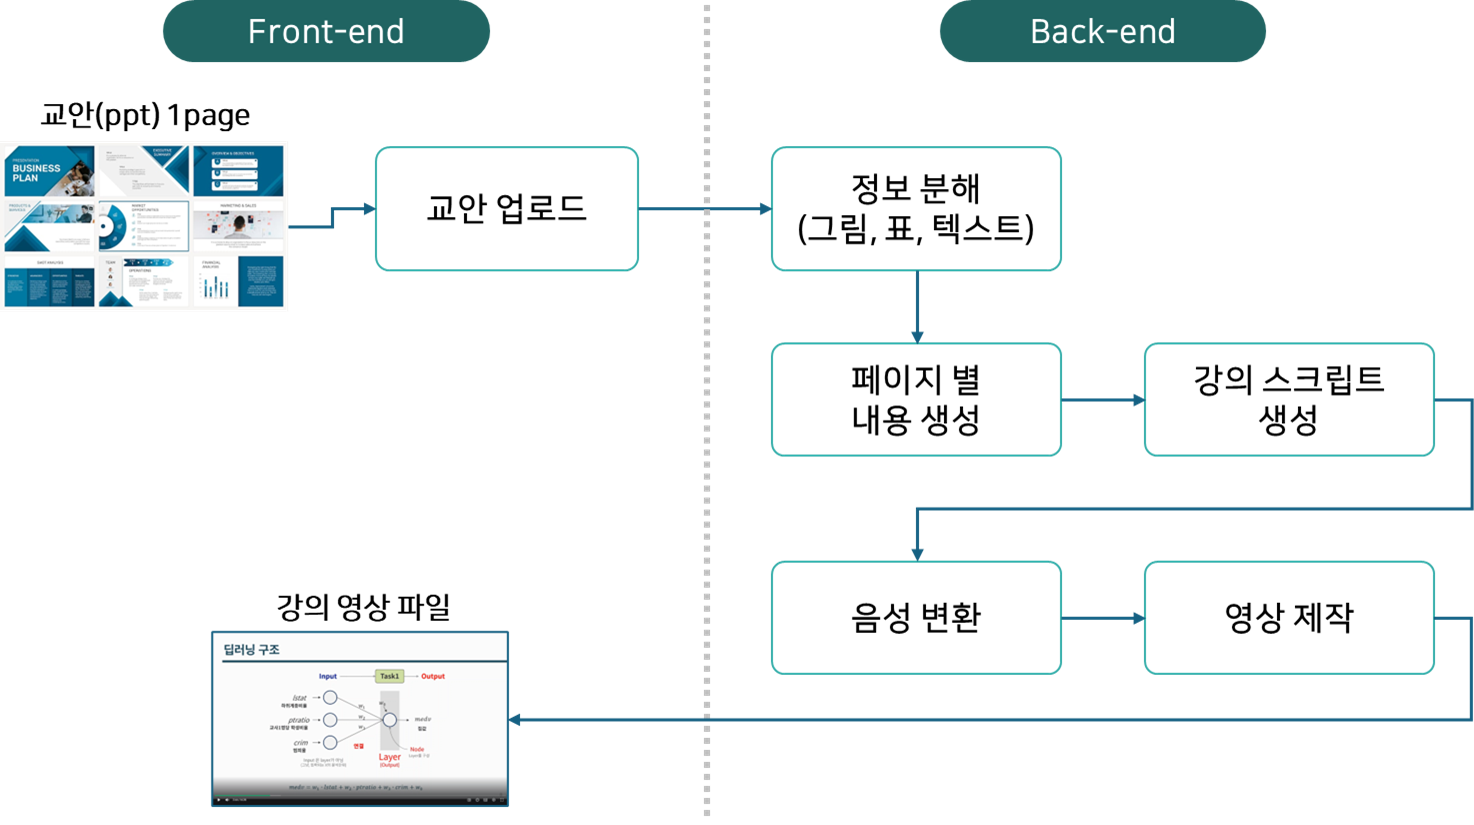

## **1. 환경준비**

### (1) 구글 드라이브

* 구글 드라이브 폴더 생성
    * 새 폴더 `proj1_agent`를 생성하고
    * 제공 받은 파일을 업로드

* 구글 드라이브 연결

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### (2) 한글 폰트 준비
* 한글 폰트 설치 및 설정 코드
* 영상 제작 등 한글 사용시 필요

In [ ]:
%%bash
set -e

# (1) 필수 패키지
sudo apt-get update -y
sudo apt-get install -y \
  libreoffice poppler-utils poppler-data ffmpeg locales fontconfig xvfb \
  fonts-noto-core fonts-noto-cjk fonts-noto-cjk-extra

# (2) 로케일
sudo sed -i 's/^# *ko_KR.UTF-8 UTF-8/ko_KR.UTF-8 UTF-8/' /etc/locale.gen
sudo locale-gen ko_KR.UTF-8
sudo update-locale LANG=ko_KR.UTF-8

# (3) 기존에 만들었던 사용자 fonts.conf(전체 덮어쓰기) 제거
rm -f ~/.config/fontconfig/fonts.conf || true

# (4) 시스템 fontconfig에 로컬 룰로만 추가 (기본 설정은 그대로 사용)
sudo tee /etc/fonts/local.conf >/dev/null <<'EOF'
<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>

  <!-- 한국어는 Noto Sans KR 우선 -->
  <match target="pattern">
    <test name="lang" compare="contains"><string>ko</string></test>
    <edit name="family" mode="prepend" binding="strong">
      <string>Noto Sans KR</string>
      <string>Noto Sans CJK KR</string>
      <string>Noto Sans</string>
    </edit>
  </match>

  <!-- 흔한 한글 폰트명을 Noto Sans KR로 매핑 -->
  <alias><family>Malgun Gothic</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>맑은 고딕</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>Apple SD Gothic Neo</family><prefer><family>Noto Sans KR</family></prefer></alias>
  <alias><family>AppleGothic</family><prefer><family>Noto Sans KR</family></prefer></alias>

</fontconfig>
EOF

# (5) 캐시 완전 재생성
rm -rf ~/.cache/fontconfig
sudo fc-cache -r
fc-cache -f -v >/dev/null

# (6) 검증
echo "---- fc-match ko ----"
fc-match "sans-serif:lang=ko"
echo "---- noto candidates ----"
fc-list | grep -i -E "noto.*(sans|cjk).*kr" | head -n 30 || true

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [354 B]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Packages [4,173 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,932 kB]
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [7,011 kB]
Get:14 http://archive.ub

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 150.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 


### (3) 라이브러리

* 필요한 라이브러리 설치

In [ ]:
!apt-get -y install ffmpeg libreoffice poppler-utils
!pip install langchain-openai langchain-community python-pptx pillow -q

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
libreoffice is already the newest version (1:7.3.7-0ubuntu0.22.04.10).
0 upgraded, 0 newly installed, 0 to remove and 22 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.7/506.7 kB 28.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency con

* 라이브러리 로딩

In [ ]:
import os, re, textwrap, subprocess, json, base64, mimetypes, shlex
from pathlib import Path
from dataclasses import dataclass
from typing import List, Dict, Optional, TypedDict
from PIL import Image, ImageDraw
from pptx import Presentation
from pptx.enum.shapes import MSO_SHAPE_TYPE
from openai import OpenAI
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

from google.colab import files
from IPython.display import Audio, display, Video

### (4) OpenAI API Key 확인
* 구글드라이브에 생성한 폴더 `proj1_agent`에
* api_key.txt 파일 안에 각자 발급 받은 openai api key를 저장합니다.

In [ ]:
def load_api_keys(filepath="api_key.txt"):
    with open(filepath, "r") as f:
        for line in f:
            line = line.strip()
            if line and "=" in line:
                key, value = line.split("=", 1)
                os.environ[key.strip()] = value.strip()

path = '/content/drive/MyDrive/proj1_agent/'
# API 키 로드 및 환경변수 설정
load_api_keys(path + 'api_key.txt')

In [ ]:
print(os.environ['OPENAI_API_KEY'][:30])

sk-6HnpTor5FDdHd3WXGaRUshfzSdb


### (5) 유용한 함수들 제공
* 다음은 프로젝트를 수행하는데 유용한 함수들입니다.
* 이 함수들의 내용을 확인하고 필요시 활용하여 개인 과제를 수행합니다.(꼭 활용해야 하는 것은 아닙니다.)

* 공백 제거 함수

In [ ]:
def clean_text(s):
    return re.sub(r"\s+", " ", s).strip()

In [ ]:
# 사용 예
raw_text = " 딥러닝    모델 \n\n 학습에는 \t 많은   데이터가 필요합니다.  "
print("* 원본:", raw_text)
print("* 정제 후:", clean_text(raw_text))

* 원본:  딥러닝    모델 

 학습에는 	 많은   데이터가 필요합니다.  
* 정제 후: 딥러닝 모델 학습에는 많은 데이터가 필요합니다.


* 긴 문자열을 문장 단위로 나누는 문장 분리기

In [ ]:
def split_sents(t: str) -> List[str]:
    parts = re.split(r'([\.?!])', t)
    merged = []
    for i in range(0, len(parts)-1, 2):
        sent = (parts[i] + parts[i+1]).strip()
        if sent: merged.append(sent)
    if len(parts) % 2 == 1 and parts[-1].strip():
        merged.append(parts[-1].strip())
    return [s for s in merged if s]

In [ ]:
# 사용 예
text = "안녕하세요. 오늘은 날씨가 좋네요! 점심 드셨어요?"
print(split_sents(text))

['안녕하세요.', '오늘은 날씨가 좋네요!', '점심 드셨어요?']


* 오디오 길이 계산

In [ ]:
def ffprobe_duration(path: str) -> float:
    out = subprocess.check_output([
        "ffprobe","-v","error","-show_entries","format=duration",
        "-of","default=noprint_wrappers=1:nokey=1", path]).decode().strip()
    return float(out)

In [ ]:
# 사용 예
uploaded = files.upload()   # 로컬 PC에서 '스티브 잡스4.mp3' 선택

mp3_file = "스티브 잡스4.mp3"
duration = ffprobe_duration(mp3_file)
print(f"{mp3_file} 길이: {duration:.2f}초")

Saving 스티브 잡스4.mp3 to 스티브 잡스4.mp3
스티브 잡스4.mp3 길이: 58.82초


In [ ]:
display(Audio(mp3_file))

* 이미지를 base64로 변환

In [ ]:
def img_to_data_url(path: str) -> str:
    mime = mimetypes.guess_type(path)[0] or "image/png"
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("utf-8")
    return f"data:{mime};base64,{b64}"

In [ ]:
# 사용 예
uploaded = files.upload()   # 로컬 PC에서 '스티브잡스_연설_이미지.png' 선택

png_path = "스티브잡스_연설_이미지.png"
data_url = img_to_data_url(png_path)
print(data_url[:100] + "...")   # 앞부분만 출력 (너무 길기 때문)

Saving 스티브잡스_연설_이미지.png to 스티브잡스_연설_이미지.png
data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAA40AAAJ4CAYAAADBfAYnAAAAAXNSR0IArs4c6QAAAARnQU1BAACxjw...


* 배경 이미지와 오디오 합쳐서 MP4 영상 만들기

In [ ]:
def render_mp4(image_path: str, audio_path: str, out_mp4: str,
               width=1920, height=1080, ):

    dur = ffprobe_duration(audio_path)

    vf = (f"scale={width}:{height}:force_original_aspect_ratio=decrease,"
          f"pad={width}:{height}:(ow-iw)/2:(oh-ih)/2:color=black"  )

    # FFmpeg 명령
    cmd = ["ffmpeg", "-y",
            "-loop", "1", "-i", image_path,   # 정지 이미지 입력
            "-i", audio_path,                 # 오디오 입력
            "-t", str(dur),                   # 길이 = 오디오 길이
            "-vf", vf,                        # 비디오 필터
            "-c:v", "libx264", "-preset", "veryfast", "-crf", "20",
            "-c:a", "aac", "-b:a", "192k",
            "-pix_fmt", "yuv420p",
            "-movflags", "+faststart",        # 웹/브라우저 재생 친화
            out_mp4]
    subprocess.check_call(cmd)  # 외부 프로그램(FFmpeg)을 파이썬 프로세스에서 실행하고, 성공했는지 확인

In [ ]:
# 사용 예
# 이미 업로드한 스티브잡스_연설_이미지.png, 스티브 잡스4.mp3 를 합성

# 예시 파일 준비
image_path = "스티브잡스_연설_이미지.png"          # PPT 슬라이드 캡처
audio_path = "스티브 잡스4.mp3"      # 해당 슬라이드 설명 음성
output_path = "video.mp4" # 합성 결과

# 함수 실행
render_mp4(image_path, audio_path, output_path)

# 영상 확인
with open(output_path, "rb") as f:
    data = f.read()

display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

Output hidden; open in https://colab.research.google.com to view.

## **2. 미션① : AI 강의 영상 제작 단계별 구축하기**

* State 정의
* 1page ppt 파일 인식 → 텍스트, 표, 그림 저장
* 정보 분석 : 텍스트, 표, 그림 등 정보로 부터 내용 정리(LLM)
* 설명 흐름 정리 및 설명문 생성(LLM)

### (1) 파일 입력

* ppt, image 업로드 코드 제공
    * `sample1.pptx` 와 `sample1.png` 제공



In [ ]:
# 파일 업로드 (1page PPTX)
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

Saving sample1.pptx to sample1.pptx


In [ ]:
# 파일 업로드 (1page image)
uploaded = files.upload()
slide_image_path = list(uploaded.keys())[0]

Saving sample1.png to sample1.png


In [ ]:
# 사용자 프롬프트
USER_PROMPT = {
    "voice": "alloy",
    "tone": "친절하고 명료한 강의 톤",
    "style": "예시와 핵심 요점 중심"
}
# 출력 dir 만들기
WORK_DIR = "./step1_output"
MEDIA_DIR = "./step1_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) State 선언

* 각 노드의 입출력 관리를 위한 State 구성
    * 각 함수(노드)에서 채워가며 관리해야 할 정보를 도출
    * 이를 하나의 State로 정의


In [ ]:
# State 정의 및 초기화
class State(TypedDict, total=False): # total=False는 TypedDict에서 모든 키를 선택(optional)으로 취급
    # 입력/기본
    pptx_path: str
    work_dir: str
    prompt: Dict
    slide_index: int          # 현재 처리 중인 슬라이드(0-based). 개인 과제는 0 고정.

    # 추출 산출물
    texts: List[str]
    tables: List[List[List[str]]]  # 리스트 안에 표를 2차원 리스트로 관리
    images: List[str]       # 이미지 path
    slide_image: List[str]  # 슬라이드 스냅샷 path (영상 배경용)

    # 생성 산출물
    page_content: str
    script: str

    # 미디어 산출물
    audio: str
    video_path: str

In [ ]:
state: State = {"pptx_path": pptx_path, "work_dir": WORK_DIR, "prompt": USER_PROMPT, 'slide_image': [slide_image_path]}
state

{'pptx_path': 'sample1.pptx',
 'work_dir': './step1_output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심'},
 'slide_image': ['sample1.png']}

* 모델 준비

In [ ]:
LLM_MODEL = "gpt-4o-mini"
TTS_MODEL = "gpt-4o-mini-tts"

In [ ]:
llm = ChatOpenAI(model=LLM_MODEL, temperature=0.3)

### (3) ppt 정보 분해
* 목적 : 첫 번째 슬라이드에서 텍스트, 표, 이미지를 추출하여 state에 저장
* 입/출력
    * 입력: state["pptx_path"] (PPTX 경로), slide_index (현재는 무시, 0고정)
    * 출력 : state["texts"], state["tables"], state["images"] 갱신
* 처리
    * 슬라이드의 각 shape 탐색
    * 텍스트 → 문단 단위 추출 후 clean_text로 정제
    * 표 → 2차원 리스트로 변환 후 저장
    * 이미지 → 파일로 저장하고 경로를 기록

* 노드 함수 생성

In [ ]:
def node_parse_ppt(state: State) -> State:
    ppt = Presentation(state["pptx_path"])

    # 첫번째 슬라이드
    slide = ppt.slides[0]

    texts, tables, images = [], [], []

    for sh in slide.shapes: # 텍스트 상자, 이미지, 표 모두가 shape
        if hasattr(sh, "has_text_frame") and sh.has_text_frame:  # 만약 텍스트라면...
            txt = "\n".join(p.text for p in sh.text_frame.paragraphs)  # 텍스트 프레임 안의 문단 단위(paragraphs) 텍스트를 줄바꿈으로 합침
            if txt.strip(): texts.append(clean_text(txt))              # 공백만 있는 텍스트는 버리고, 내용이 있으면 clean_text(연속 공백 정리)로 정제 후 texts에 추가.
        if sh.shape_type == MSO_SHAPE_TYPE.TABLE:                      # 도형 타입이 표(TABLE) 인지 확인.
            tbl = [[clean_text(c.text) for c in r.cells] for r in sh.table.rows]  # 표를 행 단위 리스트로 변환. 각 행 r의 모든 셀 c.text를 꺼내 공백 정리(clean_text) 후 2차원 리스트에 저장.
            tables.append(tbl)
        if sh.shape_type == MSO_SHAPE_TYPE.PICTURE:                    # 도형 타입이 그림(이미지) 인지 확인.
            ext = sh.image.ext              # 이미지의 원본 확장자를 얻는다(예: png, jpg).
            path = os.path.join(MEDIA_DIR, f"slide1_img_{len(images)+1}.{ext}")  # 파일 저장 경로
            with open(path, "wb") as f: f.write(sh.image.blob)         # 파일 저장
            images.append(path)

    state["texts"], state["tables"], state["images"] = texts, tables, images
    return state

* 노드 테스트

In [ ]:
# 테스트
state = node_parse_ppt(state)
print("추출:", len(state["texts"]), "texts", len(state["tables"]), "tables", len(state["images"]), "images")

추출: 3 texts 1 tables 1 images


In [ ]:
state

{'pptx_path': 'sample1.pptx',
 'work_dir': './step1_output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심'},
 'slide_image': ['sample1.png'],
 'texts': ['1',
  'ViT (Vision Transformer) 개요',
  '1. CNN의 한계 지역적 패턴 중심 학습 → 전역 문맥 학습에 약함 수용 영역(Receptive Field)은 깊어질수록 커지지만, 여전히 한계 존재 이미지 크기나 구조 변화 시 유연성이 낮음 2. Transformer의 강점 Self-Attention → 전역 정보 학습 강점 병렬 처리 / BERT, GPT 등 NLP에서 혁신적인 성과 3. ViT의 핵심 개념 이미지를 다수의 패치(patch)로 분할 → 텍스트의 단어(token)처럼 처리 각 패치를 벡터로 전환 후 위치 정보를 더해 Transformer 입력 Self-Attention으로 패치 간 전역 관계를 직접 학습'],
 'tables': [[['역량', '파라미터', '백본 LLM'],
   ['이미지 이해', 'ViT', 'CNN의 한계를 넘어 전역 문맥 학습 이미지 패치를 토큰처럼 처리'],
   ['이미지-텍스트 융합', 'CLIP', '이미지와 텍스트를 공통 임베딩 공간에 매핑 이미지-텍스트 검색, 제로 샷 분류 가능'],
   ['설명·대화 확장',
    'BLIP, LLaVA',
    '이미지 설명 생성(Image Captioning), VQA LLaVA: 대화형 시각+언어 모델 (LLM과 결합)'],
   ['완전 멀티모달',
    'Qwen2.5-omni, GPT-4o',
    '텍스트·이미지·오디오·영상까지 직접 처리 복합 모달 입력/출력을 통합적으로 처리, 실시간 추론 및 생성']]],
 'images': ['./step1_output/media/slide1_img_1

### (4) 내용 생성

* 목적 : 추출된 텍스트·표·이미지를 기반으로 LLM을 호출해 페이지 요약 문단을 생성
* 입/출력
    * 입력: state["texts"], state["tables"], state["images"], state["slide_image"], state["prompt"]
    * 출력: state["page_content"] (LLM 생성 결과 요약 문단)
* 처리
    * 표는 첫 번째 표의 앞 6행만 문자열로 변환(데이터가 너무 많아지는것 방지)
    * 이미지(최대 3개)를 data URL로 인코딩해 멀티모달 입력에 포함
    * 프롬프트 규칙(과장 금지, 4~6문장, 불릿 금지, 스타일 적용, 이미지 설명 포함) 적용
    * LLM 호출 결과를 page_content에 저장

* 노드 함수 생성

In [ ]:
def node_generate_text(state: State) -> State:
    # 1. 슬라이드에서 사용할 정보 준비 ---------------
    ## 슬라이드 텍스트
    texts = state.get("texts", [])
    ## 슬라이드 표: 첫 표 6행까지만 문자열화
    tables = state.get("tables", [])
    table_snip = ""
    if tables:
        try:
            table_snip = "\n".join([" | ".join(map(str, r)) for r in tables[0][:6]])
        except Exception:
            table_snip = str(tables[0][:6])
    ## 슬라이드 이미지
    images = list(state.get("images", []) or [])
    slide_img = state.get("slide_image") # 슬라이드 스냅샷이 있으면 가장 앞에 우선 포함
    if slide_img:
        if isinstance(slide_img, list):
            if slide_img and slide_img[0] not in images:
                images.insert(0, slide_img[0])
        else:
            if slide_img not in images:
                images.insert(0, slide_img)

    ## 사용자가 입력한 강의 스타일
    prompt = state["prompt"]

    # 2. 메시지 구성 -----------------------
    ## 시스템 메시지
    sys_msg = f"""
# 역할 : 너는 발표 슬라이드의 콘텐츠를 기반으로 핵심 내용을 정리하는 전문가다.

# 지침
- 과장하거나 추측하지 말고, 반드시 제공된 텍스트·표·이미지에만 근거해 설명한다.
- 결과는 4~6문장 분량의 자연스러운 문단으로 작성한다.
- 불릿 포인트는 사용하지 않는다.
- 스타일은 다음 지시를 따른다: {prompt.get('style')}
- 이미지가 있다면, 이미지에서 무엇이 보이는지와 그것이 텍스트/표의 어떤 내용을 보완하는지도 1~2문장 포함한다.
"""

    ## HumanMessage : 리스트로 구성해야 멀티모달 입력 가능
    user_text = []
    user_text.append(f"[텍스트]\n{texts if texts else '(없음)'}")
    user_text.append(f"[표 요약]\n{table_snip if table_snip else '(없음)'}")
    user_text = "\n\n".join(user_text)

    ### 멀티모달 HumanMessage 구성
    human_msg = [{"type": "text", "text": user_text}]

    MAX_IMGS = 3
    for image in images[:MAX_IMGS]:
        try:
            data_url = img_to_data_url(image)  # base 64 변환
            human_msg.append({"type": "image_url", "image_url": {"url": data_url}})
        except Exception:
            pass

    # 3. llm.invoke() ------------------
    response = llm.invoke([SystemMessage(content=sys_msg),
                           HumanMessage(content=human_msg)])

    state["page_content"] = response.content.strip()
    return state

* 노드 테스트

In [ ]:
# 테스트
state = node_generate_text(state)
print(state["page_content"][:200], "...")

ViT (Vision Transformer)는 CNN의 한계를 극복하기 위해 설계된 모델로, 지역적 패턴 중심의 학습에서 전역 문맥 학습으로의 전환을 목표로 합니다. CNN은 수용 영역이 깊어질수록 커지지만, 이미지 크기나 구조 변화에 대한 유연성이 낮아 한계가 존재합니다. 반면, ViT는 이미지를 여러 패치로 나누어 각 패치를 텍스트의 단어처럼 처리하고, ...


### (5) 강의 스크립트

* 목적 : 슬라이드 요약(page_content)을 기반으로 60~90초 분량의 발표 대본(스크립트)을 작성하고 저장
* 입/출력
    * 입력:
        * state["page_content"] (슬라이드 핵심 요약 문단)
        * state["prompt"] (tone 키 사용 → 말투 지시)
        * state["work_dir"] (스크립트 저장 디렉토리)
    * 출력:
        * state["script"] (생성된 발표 스크립트)
        * script.txt 파일 (work_dir 내 저장)
* 처리
    * LLM에 시스템 프롬프트(발표 대본 작성 보조 에이전트)와 사용자 요청(인트로→설명→마무리 구조, 말투, 금지 규칙)을 전달
    * LLM 응답을 문자열로 정리해 state["script"]에 저장
    * 동시에 script.txt로 파일 저장

* 노드 함수 생성

In [ ]:
def node_generate_script(state: State) -> State:
    # 1. 슬라이드에서 사용할 정보 준비 ---------------
    content = state["page_content"]
    prompt = state["prompt"]

    # 2. 메시지 구성 -----------------------
    sys_msg = """
# 역할 : 너는 발표 대본 작성 보조 에이전트다.

# 지침
- 제공된 내용을 바탕으로 발표자가 실제로 말할 수 있는 자연스러운 한국어 발표 스크립트를 작성한다.
- 결과는 60~90초 분량으로 작성한다.
- 구성은 다음 흐름을 따른다:
  1) 인트로 1문장
  2) 자연스러운 핵심 설명
  3) 마무리 1문장
- 숫자와 용어는 원문 기준으로 정확하게 유지한다.
- 불필요한 수식어와 군더더기는 줄인다.
- 불릿, 번호 목록, 코드블록은 사용하지 않는다.
"""

    human_msg = f"""
다음 내용을 토대로 발표 스크립트를 한국어로 작성해줘.

- 말투: {prompt.get('tone')}

[내용]
{content}
"""

    # 3. llm.invoke() ------------------
    response = llm.invoke([SystemMessage(content=sys_msg),
                           HumanMessage(content=human_msg)])

    state["script"] = response.content.strip()
    return state

* 테스트

In [ ]:
# 테스트
state = node_generate_script(state)
print(state["script"][:200], "...")

안녕하세요, 오늘은 ViT, 즉 Vision Transformer에 대해 말씀드리겠습니다. ViT는 CNN의 한계를 극복하기 위해 설계된 모델로, 지역적 패턴 중심의 학습에서 전역 문맥 학습으로의 전환을 목표로 하고 있습니다. 

CNN은 수용 영역이 깊어질수록 커지지만, 이미지 크기나 구조 변화에 대한 유연성이 떨어지는 한계가 있습니다. 반면, ViT는  ...


## **3. 미션② : AI 강의 영상 제작 전체 흐름 엮어내기**

* 설명문을 음성으로 변환(TTS)
* 음성과 슬라이드 스냅샷 이미지 합성하여 영상 제작하기
* 전체를 Agent 그래프로 엮기

### (1) 음성 변환

* 목적 : 발표 스크립트(script)를 TTS 모델을 이용해 음성(mp3) 파일로 변환하고 state에 저장
* 입/출력
    * 입력:
        * state["script"] (발표 대본 텍스트)
        * state["prompt"]["voice"] (선택적, 목소리 프리셋. 기본값 "alloy")
        * state["work_dir"] (오디오 저장 위치)
    * 출력:
        * state["audio"] (생성된 mp3 파일 경로)
        * 콘솔 출력: MP3 길이(sec)
* 처리
    * OpenAI TTS 모델(TTS_MODEL)에 스크립트와 목소리 옵션 전달
    * 응답 받은 음성 데이터를 narration.mp3 파일로 저장
    * ffprobe_duration()으로 생성된 MP3 길이 확인 후 콘솔에 출력
    * state["audio"]에 파일 경로 기록

* 노드 함수 생성

In [ ]:
def node_tts(state: State) -> State:
    client = OpenAI()

    resp = client.audio.speech.create(
                model=TTS_MODEL,
                voice=state["prompt"].get("voice", "alloy"),
                input=state["script"] )

    # 파일 저장
    mp3_path = os.path.join(state["work_dir"], "narration.mp3")
    with open(mp3_path, "wb") as f:
        f.write(resp.content)

    state["audio"] = mp3_path
    print("MP3 길이:", ffprobe_duration(mp3_path), "sec")
    return state

* 노드 테스트

In [ ]:
# 테스트
state = node_tts(state)

MP3 길이: 76.056 sec


In [ ]:
# 오디오 play 예시 코드
from IPython.display import Audio, display
audio_path = state["audio"]
display(Audio(filename=audio_path))
print("Audio file:", audio_path)

Audio file: ./step1_output/narration.mp3


### (2) 영상 제작
* 목적 : 슬라이드 이미지와 음성을 합쳐 mp4 영상 생성
* 입/출력
    * 입력: state["slide_image"][0], state["audio"], state["work_dir"], state["slide_index"]
    * 출력: state["video_path"] (생성된 mp4 경로)
* 처리
    * 첫 번째 슬라이드 이미지를 배경으로 선택
    * 오디오(mp3)와 함께 render_mp4() 호출
    * 결과 영상을 slideN_lecture.mp4로 저장 후 경로 기록

* 노드 함수 생성

In [ ]:
def node_make_video(state: State) -> State:
    # 1. 슬라이드 PNG
    img = state.get("slide_image")[0]  # 첫번째 이미지

    # 2. 오디오 경로
    audio_path = state["audio"]

    # 3. 렌더
    out_mp4 = os.path.join(state["work_dir"], f"slide{state.get('slide_index',0)+1}_lecture.mp4")
    render_mp4(img, audio_path, out_mp4)

    state["video_path"] = out_mp4
    return state

* 노드 테스트

In [ ]:
# 테스트
state = node_make_video(state)

In [ ]:
state

{'pptx_path': 'sample1.pptx',
 'work_dir': './step1_output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심'},
 'slide_image': ['sample1.png'],
 'texts': ['1',
  'ViT (Vision Transformer) 개요',
  '1. CNN의 한계 지역적 패턴 중심 학습 → 전역 문맥 학습에 약함 수용 영역(Receptive Field)은 깊어질수록 커지지만, 여전히 한계 존재 이미지 크기나 구조 변화 시 유연성이 낮음 2. Transformer의 강점 Self-Attention → 전역 정보 학습 강점 병렬 처리 / BERT, GPT 등 NLP에서 혁신적인 성과 3. ViT의 핵심 개념 이미지를 다수의 패치(patch)로 분할 → 텍스트의 단어(token)처럼 처리 각 패치를 벡터로 전환 후 위치 정보를 더해 Transformer 입력 Self-Attention으로 패치 간 전역 관계를 직접 학습'],
 'tables': [[['역량', '파라미터', '백본 LLM'],
   ['이미지 이해', 'ViT', 'CNN의 한계를 넘어 전역 문맥 학습 이미지 패치를 토큰처럼 처리'],
   ['이미지-텍스트 융합', 'CLIP', '이미지와 텍스트를 공통 임베딩 공간에 매핑 이미지-텍스트 검색, 제로 샷 분류 가능'],
   ['설명·대화 확장',
    'BLIP, LLaVA',
    '이미지 설명 생성(Image Captioning), VQA LLaVA: 대화형 시각+언어 모델 (LLM과 결합)'],
   ['완전 멀티모달',
    'Qwen2.5-omni, GPT-4o',
    '텍스트·이미지·오디오·영상까지 직접 처리 복합 모달 입력/출력을 통합적으로 처리, 실시간 추론 및 생성']]],
 'images': ['./step1_output/media/slide1_img_1

In [ ]:
# 동영상 play 예시 코드
video_path = state["video_path"]

with open(video_path, "rb") as f:
    data = f.read()

display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

Output hidden; open in https://colab.research.google.com to view.

### (3) Agent 만들기 : 그래프로 엮기
* 다음 그래프를 참조하여 하나의 에이전트로 엮어 봅시다.

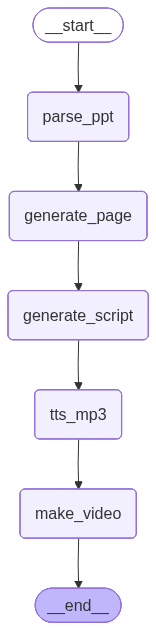

In [ ]:
from langgraph.graph import StateGraph, END
builder = StateGraph(State)

builder.add_node("parse_ppt",            node_parse_ppt)
builder.add_node("generate_page",        node_generate_text)
builder.add_node("generate_script",      node_generate_script)
builder.add_node("tts_mp3",              node_tts)
builder.add_node("make_video",           node_make_video)

builder.set_entry_point("parse_ppt")
builder.add_edge("parse_ppt",       "generate_page")
builder.add_edge("generate_page",   "generate_script")
builder.add_edge("generate_script", "tts_mp3")
builder.add_edge("tts_mp3",         "make_video")
builder.add_edge("make_video",      END)

app = builder.compile()

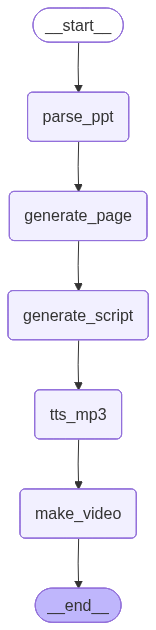

In [ ]:
app

## **4. 시스템 실행**

미션1,2에서 수행한 결과를 통합 테스트 해 봅시다.

### (1) 준비 작업
* 파일 업로드
* 사용자 프롬프트 준비

In [ ]:
# 파일 업로드 (1page PPTX)
uploaded = files.upload()
pptx_path = list(uploaded.keys())[0]

Saving sample1.pptx to sample1 (1).pptx


In [ ]:
# 파일 업로드 (1page image)
uploaded = files.upload()
slide_image_path = list(uploaded.keys())[0]

Saving sample1.png to sample1 (1).png


In [ ]:
# 사용자 프롬프트
USER_PROMPT = {
    "voice": "alloy",
    "tone": "친절하고 명료한 강의 톤",
    "style": "예시와 핵심 요점 중심"
}
# 출력 dir 만들기
WORK_DIR = "./step1_output"
MEDIA_DIR = "./step1_output/media"
os.makedirs(WORK_DIR, exist_ok=True)
os.makedirs(MEDIA_DIR, exist_ok=True)

### (2) Agent 실행
* State 초기화
* app 실행
* 동영상 play

In [ ]:
state: State = {"pptx_path": pptx_path, "work_dir": WORK_DIR,
                "prompt": USER_PROMPT, 'slide_image': [slide_image_path]}
state

{'pptx_path': 'sample1 (1).pptx',
 'work_dir': './step1_output',
 'prompt': {'voice': 'alloy',
  'tone': '친절하고 명료한 강의 톤',
  'style': '예시와 핵심 요점 중심'},
 'slide_image': ['sample1 (1).png']}

In [ ]:
# 전체 그래프 실행
final_state = app.invoke(state)

# 영상 재생
video_path = final_state.get("video_path")
print("최종 영상:", video_path)

with open(video_path, "rb") as f:
    data = f.read()
display(Video(data=data, embed=True, mimetype="video/mp4", width=960))

Output hidden; open in https://colab.research.google.com to view.